In [23]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import warnings

%store -r varnames

for name in varnames:
    %store -r $name

In [24]:
def numerical_hessian(fun, x, rel_step=1e-4, abs_step=1e-6):
    """
    Central-difference numerical Hessian.
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    H = np.zeros((n, n), dtype=float)

    # parameter-dependent step sizes
    h = np.maximum(abs_step, rel_step * np.maximum(np.abs(x), 1.0))

    f0 = fun(x)

    for i in range(n):
        for j in range(i, n):
            if i == j:
                xp = x.copy()
                xm = x.copy()
                xp[i] += h[i]
                xm[i] -= h[i]

                fp = fun(xp)
                fm = fun(xm)

                H[i, i] = (fp - 2.0 * f0 + fm) / (h[i] ** 2)
            else:
                xpp = x.copy()
                xpm = x.copy()
                xmp = x.copy()
                xmm = x.copy()

                xpp[i] += h[i]; xpp[j] += h[j]
                xpm[i] += h[i]; xpm[j] -= h[j]
                xmp[i] -= h[i]; xmp[j] += h[j]
                xmm[i] -= h[i]; xmm[j] -= h[j]

                fpp = fun(xpp)
                fpm = fun(xpm)
                fmp = fun(xmp)
                fmm = fun(xmm)

                Hij = (fpp - fpm - fmp + fmm) / (4.0 * h[i] * h[j])
                H[i, j] = Hij
                H[j, i] = Hij

    return H

In [25]:
# Define stat model
# params = list of length 6
# mcvals = dict of length 4 (corresponding to region),
#          each value is a dict of length 6 (corresponding to data type),
#          each value is a np array corresponding to the hist mc data
# dvals = dict of length 4 (corresponding to region),
#         each value is a np array corresponding to the hist real data
def nll(params):
    a_ttg, a_wg, a_zg, a_other, a_misid, a_np, theta_ttg = params

    # enforce positivity
    if a_ttg < 0 or a_wg <= 0 or a_zg <= 0 or a_other <= 0 or a_misid <= 0 or a_np <= 0:
        return np.inf

    kappa_ttg = 1.05 # 10% ln(N) uncertainty

    # define prediction
    preds_all_regions = []
    for key in mcvals.keys():
        preds = (a_ttg * (kappa_ttg ** theta_ttg) * mcvals[key]["ttgamma"]
            + a_wg * mcvals[key]["WG"]
            + a_zg * mcvals[key]["ZG"]
            + a_other * mcvals[key]["other"]
            + a_misid * mcvals[key]["MisID"]
            + a_np * mcvals[key]["NonPrompt"])*1.
        if np.any(preds <= 0):
            return np.inf
        preds_all_regions.append(preds)
    # define data
    data_all_regions = []
    for key in dvals.keys():
        data_all_regions.append(
            dvals[key]
        )
        
    nll = []
    for preds, data in zip(preds_all_regions, data_all_regions):
        nll.append(
            np.sum(preds - data * np.log(preds))
        )
    nll = np.sum(nll) + 0.5*theta_ttg**2
    return nll

In [26]:
x0 = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0]
bounds=[(0, None), (0, None), (0, None), (0, None), (0, None), (0, None), (None, None)]
result = minimize(nll, x0, method="L-BFGS-B", bounds=bounds)

bf_params = np.asarray(result.x, dtype=float)
min_nll = result.fun

H_num = numerical_hessian(nll, bf_params, rel_step=1e-4, abs_step=1e-6)

# symmetrize just in case
H_num = 0.5 * (H_num + H_num.T)

# covariance = inverse Hessian
cov_freq = np.linalg.pinv(H_num)

bf_params_freq = {
        "ttgamma":   bf_params[0],
        "WG":        bf_params[1],
        "ZG":        bf_params[2],
        "other":     bf_params[3],
        "MisID":     bf_params[4],
        "NonPrompt": bf_params[5],
        "theta":     bf_params[6],
}


print("Numerical covariance matrix:\n", cov_freq)

%store bf_params_freq
%store cov_freq

Numerical covariance matrix:
 [[ 3.97541889e-03  3.85112485e-04  1.79414113e-04 -4.06711801e-03
   2.32163157e-04 -4.27743906e-05 -5.04890704e-02]
 [ 3.85112485e-04  8.83756367e-04 -1.36439898e-03 -1.64972464e-03
   2.19786988e-04  6.25288721e-07  2.42608757e-06]
 [ 1.79414113e-04 -1.36439898e-03  4.37900429e-03 -5.78237491e-04
  -3.18566521e-04 -8.08459834e-06  8.37229374e-06]
 [-4.06711801e-03 -1.64972464e-03 -5.78237491e-04  1.54859379e-02
  -2.37092828e-03 -4.40086321e-05 -4.32734762e-05]
 [ 2.32163157e-04  2.19786988e-04 -3.18566521e-04 -2.37092828e-03
   4.17766306e-03 -7.82045152e-05  3.92138461e-06]
 [-4.27743906e-05  6.25288721e-07 -8.08459834e-06 -4.40086321e-05
  -7.82045152e-05  1.06350573e-04 -4.32195669e-07]
 [-5.04890704e-02  2.42608757e-06  8.37229374e-06 -4.32734762e-05
   3.92138460e-06 -4.32195669e-07  9.90733042e-01]]
Stored 'bf_params_freq' (dict)
Stored 'cov_freq' (ndarray)


In [27]:
# The following is flawed! Does not compute hessian exactly, only approximates, leading to huge error bars.

x0 = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0]
bounds=[(0, None), (0, None), (0, None), (0, None), (0, None), (0, None), (None, None)]
result = minimize(nll, x0, method="L-BFGS-B", bounds=bounds)
print("Best-fit parameters:", result.x)
print("Minimum NLL:", result.fun)

bf_params = result.x
min_nll = result.fun

bf_params_freq = {
        "ttgamma":   bf_params[0],
        "WG":        bf_params[1],
        "ZG":        bf_params[2],
        "other":     bf_params[3],
        "MisID":     bf_params[4],
        "NonPrompt": bf_params[5],
        "theta":     bf_params[6],
}

# approximate covariance from inverse Hessian
cov_freq = result.hess_inv.todense()
cov_freq = np.asarray(cov_freq, dtype=float)

print("Approximate covariance matrix:\n", cov_freq)

#%store bf_params_freq
#%store cov_freq

Best-fit parameters: [ 1.04478109  0.8581329   1.05849812  0.97613861  2.5290458   0.90920665
 -0.00388439]
Minimum NLL: -287995.8593799819
Approximate covariance matrix:
 [[ 0.59137743  0.22408747 -1.16670652 -0.44253288 -0.8831118  -0.1446779
  -0.01987463]
 [ 0.22408747  0.16919189 -0.5951984  -0.41057852 -0.1634524  -0.05250832
   0.01332232]
 [-1.16670652 -0.5951984   2.59785378  1.30191201  1.45337053  0.28103008
  -0.06078961]
 [-0.44253288 -0.41057852  1.30191201  1.04898943  0.14919349  0.10116645
  -0.02623531]
 [-0.8831118  -0.1634524   1.45337053  0.14919349  1.70549715  0.22063387
  -0.04705408]
 [-0.1446779  -0.05250832  0.28103008  0.10116645  0.22063387  0.03617751
  -0.00749153]
 [-0.01987463  0.01332232 -0.06078961 -0.02623531 -0.04705408 -0.00749153
   0.99901556]]


[-0.06357506  0.06436464]
95% Confidence Interval = 13.980 - 17.728


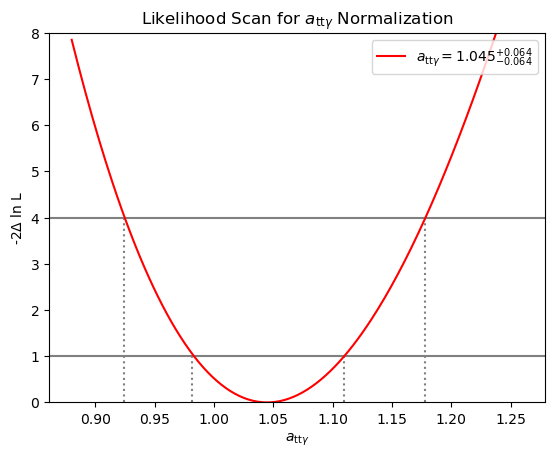

In [28]:
# plot

mu_vals = np.linspace(0.88, 1.26, 200)
profile_nll = []
ymax=8

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    for mu in mu_vals:
    
        def nll_fixed_mu(params):
            a_wg, a_zg, a_other, a_misid, a_np, theta_ttg = params
            return nll([mu, a_wg, a_zg, a_other, a_misid, a_np, theta_ttg])
    
        res = minimize(nll_fixed_mu, [1.0, 1.0, 1.0, 1.0, 1.0, 0.0])
        profile_nll.append(2*res.fun)

profile_nll = np.array(profile_nll)
profile_nll_norm = profile_nll - np.min(profile_nll)

crossings_1 = np.where(np.diff(np.sign(profile_nll_norm - 1.)) != 0)[0]
pairs_1 = [(i, i+1) for i in crossings_1]
mu_crossings_1 = [mu_vals[pairs_1[0][0]], mu_vals[pairs_1[1][0]]]
mu_errs_1 = mu_crossings_1 - bf_params[0]
print(mu_errs_1)

crossings_4 = np.where(np.diff(np.sign(profile_nll_norm - 4.)) != 0)[0]
pairs_4 = [(i, i+1) for i in crossings_4]
mu_crossings_4 = [mu_vals[pairs_4[0][0]], mu_vals[pairs_4[1][0]]]
mu_errs_4 = mu_crossings_4 - bf_params[0]

crossings_95 = np.where(np.diff(np.sign(profile_nll_norm - 3.84)) != 0)[0]
pairs_95 = [(i, i+1) for i in crossings_95]
mu_crossings_95 = [mu_vals[pairs_95[0][0]], mu_vals[pairs_95[1][0]]]
mu_errs_95 = mu_crossings_95 - bf_params[0]

th_sigma = 15.10
print(f"95% Confidence Interval = {mu_crossings_95[0]*th_sigma:.3f} - {mu_crossings_95[1]*th_sigma:.3f}")

plt.clf()
plt.axhline(y=1, c = 'gray')
plt.axhline(y=4, c = 'gray')
plt.axvline(x=mu_crossings_1[0], c = 'gray', ymin=0, ymax=1./ymax, linestyle=":")
plt.axvline(x=mu_crossings_1[1], c = 'gray', ymin=0, ymax=1./ymax, linestyle=":")
plt.axvline(x=mu_crossings_4[0], c = 'gray', ymin=0, ymax=4./ymax, linestyle=":")
plt.axvline(x=mu_crossings_4[1], c = 'gray', ymin=0, ymax=4./ymax, linestyle=":")
plt.plot(mu_vals, profile_nll_norm, c="red", label=r"$a_{\mathrm{tt}\gamma} = 1.045^{+0.064}_{-0.064}$")
plt.legend(loc='upper right')
plt.xlabel(r"$a_{\mathrm{tt}\gamma}$")
plt.ylabel(r"-2$\Delta$ ln L")
plt.ylim(0., ymax)
plt.title(r"Likelihood Scan for $a_{\mathrm{tt}\gamma}$ Normalization")
plt.show()


In [29]:
# Find the final measured cross-section with errors

th_sigma = 15.10
errs = mu_errs_1 * th_sigma
sigma = bf_params_freq["ttgamma"] * th_sigma
print(f"mu = {sigma:.3f}^{+errs[1]:.3f}_{-errs[0]:.3f}")

mu = 15.776^0.972_0.960


In [30]:
# Do stat-only

# Define stat model
# params = list of length 6
# mcvals = dict of length 4 (corresponding to region),
#          each value is a dict of length 6 (corresponding to data type),
#          each value is a np array corresponding to the hist mc data
# dvals = dict of length 4 (corresponding to region),
#         each value is a np array corresponding to the hist real data
def nll_stat_only(params):
    a_ttg, a_wg, a_zg, a_other, a_misid, a_np = params
    theta_ttg = bf_params_freq['theta']

    # enforce positivity
    if a_ttg < 0 or a_wg <= 0 or a_zg <= 0 or a_other <= 0 or a_misid <= 0 or a_np <= 0:
        return np.inf

    kappa_ttg = 1.05 # 10% ln(N) uncertainty

    # define prediction
    preds_all_regions = []
    for key in mcvals.keys():
        preds = (a_ttg * (kappa_ttg ** theta_ttg) * mcvals[key]["ttgamma"]
            + a_wg * mcvals[key]["WG"]
            + a_zg * mcvals[key]["ZG"]
            + a_other * mcvals[key]["other"]
            + a_misid * mcvals[key]["MisID"]
            + a_np * mcvals[key]["NonPrompt"])*1.
        if np.any(preds <= 0):
            return np.inf
        preds_all_regions.append(preds)
    # define data
    data_all_regions = []
    for key in dvals.keys():
        data_all_regions.append(
            dvals[key]
        )
        
    nll = []
    for preds, data in zip(preds_all_regions, data_all_regions):
        nll.append(
            np.sum(preds - data * np.log(preds))
        )
    nll = np.sum(nll) + 0.5*theta_ttg**2
    return nll

In [31]:
x0_stat_only = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
bounds_stat_only=[(0, None), (0, None), (0, None), (0, None), (0, None), (0, None)]
result_stat_only = minimize(nll_stat_only, x0_stat_only, method="L-BFGS-B", bounds=bounds_stat_only)
print("Best-fit parameters:", result_stat_only.x)
print("Minimum NLL:", result_stat_only.fun)

bf_params_stat_only = result_stat_only.x
min_nll_stat_only = result_stat_only.fun

bf_params_freq_stat_only = {
        "ttgamma":   bf_params_stat_only[0],
        "WG":        bf_params_stat_only[1],
        "ZG":        bf_params_stat_only[2],
        "other":     bf_params_stat_only[3],
        "MisID":     bf_params_stat_only[4],
        "NonPrompt": bf_params_stat_only[5],
}

%store bf_params_freq_stat_only

Best-fit parameters: [1.04485166 0.85817961 1.058311   0.97602347 2.5289786  0.90919398]
Minimum NLL: -287995.85939633974
Stored 'bf_params_freq_stat_only' (dict)


[-0.06357506  0.06436464]
[-0.03882151  0.03565085]
95% Confidence Interval = 13.980 - 17.728


<Figure size 640x480 with 0 Axes>

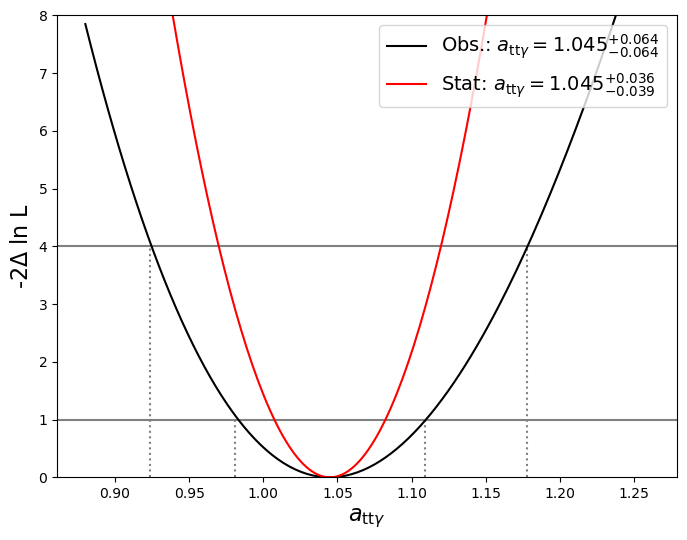

In [40]:
# plot

mu_vals = np.linspace(0.88, 1.26, 200)
profile_nll = []
profile_nll_stat_only = []
ymax=8

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    for mu in mu_vals:
    
        def nll_fixed_mu(params):
            a_wg, a_zg, a_other, a_misid, a_np, theta_ttg = params
            return nll([mu, a_wg, a_zg, a_other, a_misid, a_np, theta_ttg])

        def nll_fixed_mu_stat_only(params):
            a_wg, a_zg, a_other, a_misid, a_np = params
            return nll_stat_only([mu, a_wg, a_zg, a_other, a_misid, a_np])
    
        res = minimize(nll_fixed_mu, [1.0, 1.0, 1.0, 1.0, 1.0, 0.0])
        res_stat_only = minimize(nll_fixed_mu_stat_only, [1.0, 1.0, 1.0, 1.0, 1.0])
        profile_nll.append(2*res.fun)
        profile_nll_stat_only.append(2*res_stat_only.fun)

profile_nll = np.array(profile_nll)
profile_nll_norm = profile_nll - np.min(profile_nll)
profile_nll_stat_only = np.array(profile_nll_stat_only)
profile_nll_norm_stat_only = profile_nll_stat_only - np.min(profile_nll_stat_only)

crossings_1 = np.where(np.diff(np.sign(profile_nll_norm - 1.)) != 0)[0]
pairs_1 = [(i, i+1) for i in crossings_1]
mu_crossings_1 = [mu_vals[pairs_1[0][0]], mu_vals[pairs_1[1][0]]]
mu_errs_1 = mu_crossings_1 - bf_params[0]
print(mu_errs_1)

crossings_1_stat_only = np.where(np.diff(np.sign(profile_nll_norm_stat_only - 1.)) != 0)[0]
pairs_1_stat_only = [(i, i+1) for i in crossings_1_stat_only]
mu_crossings_1_stat_only = [mu_vals[pairs_1_stat_only[0][0]], mu_vals[pairs_1_stat_only[1][0]]]
mu_errs_1_stat_only = mu_crossings_1_stat_only - bf_params_stat_only[0]
print(mu_errs_1_stat_only)

crossings_4 = np.where(np.diff(np.sign(profile_nll_norm - 4.)) != 0)[0]
pairs_4 = [(i, i+1) for i in crossings_4]
mu_crossings_4 = [mu_vals[pairs_4[0][0]], mu_vals[pairs_4[1][0]]]
mu_errs_4 = mu_crossings_4 - bf_params[0]

crossings_95 = np.where(np.diff(np.sign(profile_nll_norm - 3.84)) != 0)[0]
pairs_95 = [(i, i+1) for i in crossings_95]
mu_crossings_95 = [mu_vals[pairs_95[0][0]], mu_vals[pairs_95[1][0]]]
mu_errs_95 = mu_crossings_95 - bf_params[0]

th_sigma = 15.10
print(f"95% Confidence Interval = {mu_crossings_95[0]*th_sigma:.3f} - {mu_crossings_95[1]*th_sigma:.3f}")

plt.clf()
label_size = 16
legend_size = 14
plt.figure(figsize=(8, 6))
plt.axhline(y=1, c = 'gray')
plt.axhline(y=4, c = 'gray')
plt.axvline(x=mu_crossings_1[0], c = 'gray', ymin=0, ymax=1./ymax, linestyle=":")
plt.axvline(x=mu_crossings_1[1], c = 'gray', ymin=0, ymax=1./ymax, linestyle=":")
plt.axvline(x=mu_crossings_4[0], c = 'gray', ymin=0, ymax=4./ymax, linestyle=":")
plt.axvline(x=mu_crossings_4[1], c = 'gray', ymin=0, ymax=4./ymax, linestyle=":")
plt.plot(mu_vals, profile_nll_norm, c="black", label=r"Obs.: $a_{\mathrm{tt}\gamma} = 1.045^{+0.064}_{-0.064}$")
plt.plot(mu_vals, profile_nll_norm_stat_only, c="red", label=r"Stat: $a_{\mathrm{tt}\gamma} = 1.045^{+0.036}_{-0.039}$")
plt.xlabel(r"$a_{\mathrm{tt}\gamma}$", fontsize=label_size)
plt.ylabel(r"-2$\Delta$ ln L", fontsize=label_size)
plt.legend(loc='upper right', fontsize=legend_size)
plt.ylim(0., ymax)
#plt.title(r"Likelihood Scan for $a_{\mathrm{tt}\gamma}$ Normalization")
plt.savefig("./Plots/freq_likelihood.png", dpi=300)
plt.show()


In [33]:
# find the syst and stat pieces

mu_syst = np.sqrt(mu_errs_1**2 - mu_errs_1_stat_only**2)
print(mu_syst * 15.10)
print(mu_errs_1_stat_only*15.10)
print(mu_errs_1*15.10)

[0.76021838 0.80919994]
[-0.5862048   0.53832786]
[-0.95998337  0.97190608]


In [34]:
# find the same for higgs combine

mu_errs_higgs = np.array([.061, .065])
mu_errs_higgs_stat = np.array([.025, .025])
mu_syst = np.sqrt(mu_errs_higgs**2 - mu_errs_higgs_stat**2)
print(mu_syst * 15.10)
print(mu_errs_higgs_stat*15.10)
print(mu_errs_higgs*15.10)

[0.84018984 0.906     ]
[0.3775 0.3775]
[0.9211 0.9815]
